# Customer Segmentation using E-Commerce Data


### 1: Import Libraries

- **pandas** → Used for data loading, cleaning, and manipulation of datasets.  
- **numpy** → Used for numerical operations and handling arrays efficiently.  
- **matplotlib.pyplot** → Used for basic data visualization like plots and charts.  
- **seaborn** → Used for advanced and more attractive statistical visualizations.  
- **StandardScaler (sklearn.preprocessing)** → Used to normalize data so all features have equal scale.  
- **KMeans (sklearn.cluster)** → Used to perform clustering by grouping similar customers together.  
- **DBSCAN (sklearn.cluster)** → Used for density-based clustering to detect patterns and outliers.  
- **silhouette_score (sklearn.metrics)** → Used to evaluate how well the clustering model is performing.  

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

### 2: Load Dataset
- **encoding='ISO-8859-1'** → Ensures proper reading of special characters ($) and avoids decoding errors.
- **df.head()** → Displays the first 5 rows to preview the dataset structure.  



In [ ]:
df = pd.read_csv('./data.csv', encoding='ISO-8859-1')
df.head()

### 3: Dataset Overview
- **df.info()** → Provides a summary of the dataset, including column names, data types, and non-null values.  
- **df.describe()** → Generates a statistical summary such as mean, standard deviation, min, and max values for numerical columns. 
- **df.isnull().sum()** → Identifies missing values in each column of the dataset.  



In [ ]:
print("Dataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

### 4: Data Preprocessing
- **df = df.dropna(subset=['CustomerID'])** → Removes missing customer IDs
- **df = df[df['Quantity'] > 0]** → Remove negative quantity (returns)
- **df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])** → Convert Date
- **df['TotalPrice'] = df['Quantity'] * df['UnitPrice']** → Create Total Price


In [7]:
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

### 5: Dataset Overview After Preprocessing the data


In [8]:
print("Dataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.DataFrame'>
Index: 397924 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397924 non-null  str           
 1   StockCode    397924 non-null  str           
 2   Description  397924 non-null  str           
 3   Quantity     397924 non-null  int64         
 4   InvoiceDate  397924 non-null  datetime64[us]
 5   UnitPrice    397924 non-null  float64       
 6   CustomerID   397924 non-null  float64       
 7   Country      397924 non-null  str           
 8   TotalPrice   397924 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 30.4 MB
None

Statistical Summary:
            Quantity                 InvoiceDate      UnitPrice  \
count  397924.000000                      397924  397924.000000   
mean       13.021823  2011-07-10 23:43:36.912476       3.116174   
min         1.000000         2010-12

### 6: Feature Engineering (RFM Model)

- **R (Recency)** → Measures how recently a customer made a purchase. Lower recency indicates more recent activity.  
- **F (Frequency)** → Represents how often a customer makes purchases. Higher frequency indicates loyal customers.  
- **M (Monetary)** → Calculates the total amount spent by a customer. Higher monetary value indicates high-value customers.  
- **Grouping by CustomerID** → Aggregates transaction data at the customer level to compute RFM metrics.  
- **Snapshot Date** → A reference date used to calculate recency by comparing with the last purchase date. 
- **Feature Transformation** → Converts raw transactional data into meaningful customer behavior features.  
- This step is crucial as it transforms the dataset into a format suitable for customer segmentation using clustering algorithms.

In [9]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head(5)

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


### 7: Data Scaling

- **StandardScaler** → Used to bring all values to a similar range.  

- **Why Scaling?** → Some features (like Monetary) have large values, while others (like Recency) are smaller. This can affect the model.  

- **What it does** → Converts data so all features are treated equally.

- **Apply log transformation** → The standard industry fix for skewed RFM distributions. log1p() means log(1+x) It compresses huge values smoothly.

**We use scaled data for modeling but original RFM values for interpretation and business insights.**

In [10]:
rfm_log = np.log1p(rfm)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary']).head(5)

,Recency,Frequency,Monetary
0,1.462236,-2.432827,3.696168
1,-2.038611,1.177369,1.408758
2,0.373310,-0.216521,0.715517
3,-0.622914,0.453609,0.697821
4,1.424800,-0.676446,-0.615877


### 8: Finding Optimal Clusters (Elbow Method)

- **Elbow Method** → Helps us find the best number of clusters (K).

- **Idea**: We try different values of K and see how the error (WCSS) changes. 

- **Elbow Point** → The point where the graph starts bending (like an elbow).  

- This point is considered the best number of clusters.

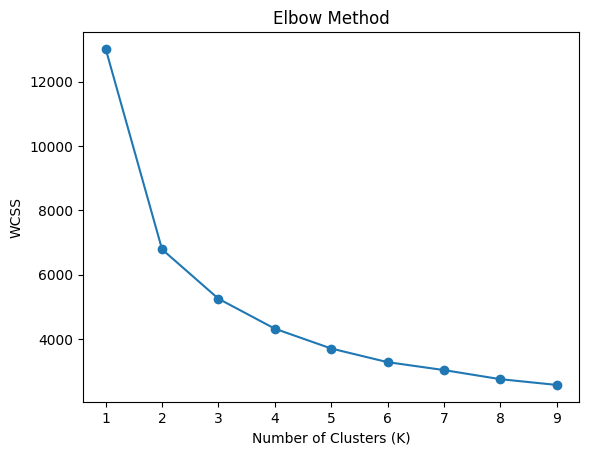

In [11]:
wcss = []

for k in range(1, 10):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(rfm_scaled)
    wcss.append(model.inertia_)

plt.plot(range(1, 10), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

- **Elbow Method** → Big drop from K=1 → K=2, good drop until K=3/4 falttens after 4/5 (So the “elbow” is around K = 3, 4 or 5)

In [12]:
for k in range(2, 10):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    print(f"K={k}, Silhouette Score={score}")

K=2, Silhouette Score=0.3987585401804808
K=3, Silhouette Score=0.3030282272383431
K=4, Silhouette Score=0.3082848091892372
K=5, Silhouette Score=0.2763452142678691
K=6, Silhouette Score=0.27370149650774295
K=7, Silhouette Score=0.2661359545106122
K=8, Silhouette Score=0.25793640774462767
K=9, Silhouette Score=0.2591684567687764


### 9: K-Means Clustering

- **K-Means** → Groups customers based on similar behavior (RFM values). 

- **Cluster Assignment** → Each customer is assigned to a cluster. 

- **Visualization** → A scatter plot is used to see how customers are grouped. 

- **Color Representation** → Each color represents a different cluster. 

- This helps us easily understand customer segments visually.

In [13]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print("Cluster Distribution:")
print(rfm['Cluster'].value_counts().sort_index())

cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

print("\nCluster Summary (Original RFM values):")
print(cluster_summary)

Cluster Distribution:
Cluster
0     872
1     867
2    1378
3    1222
Name: count, dtype: int64

Cluster Summary (Original RFM values):
            Recency   Frequency     Monetary
Cluster                                     
0         19.894495   38.746560   612.062455
1         12.907728  283.113033  7042.875479
2        185.166183   14.960087   298.374413
3         96.349427   80.247954  1522.386630


* **Initial clustering showed strong skewness caused by high-value customers.**
* **Log transformation was applied to normalize feature distribution and improve clustering quality.**
* **PCA is projecting 3D behavior into 2D.**
* **overlap is expected and perfectly separated circles are unrealistic in real customer data**
* **1 customer = 1 row in RFM, and 1 customer has many purchases; that's why we have ~ 4300 RFM Rows (~350,000 transactions in filtered dataset)**

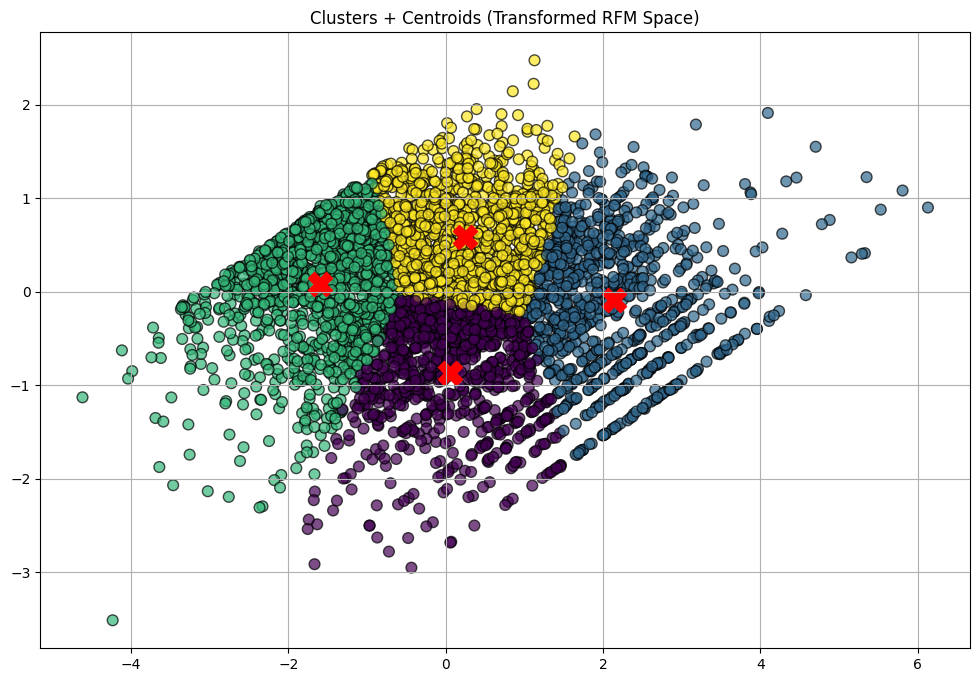

In [14]:
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

rfm['PCA1'] = rfm_pca[:, 0]
rfm['PCA2'] = rfm_pca[:, 1]

centers = kmeans.cluster_centers_
center_pca = pca.transform(centers)

plt.figure(figsize=(12, 8))

plt.scatter(
    rfm['PCA1'],
    rfm['PCA2'],
    c=rfm['Cluster'],
    cmap='viridis',
    s=60,
    alpha=0.7,
    edgecolors='k'
)

plt.scatter(
    center_pca[:, 0],
    center_pca[:, 1],
    c='red',
    s=300,
    marker='X'
)

plt.title("Clusters + Centroids (Transformed RFM Space)")
plt.grid(True)
plt.show()

### Part 2. **Predict a Customer Churn (Which customers are likely to stop using a service) / VIP**

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       578
           1       1.00      1.00      1.00       290

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868



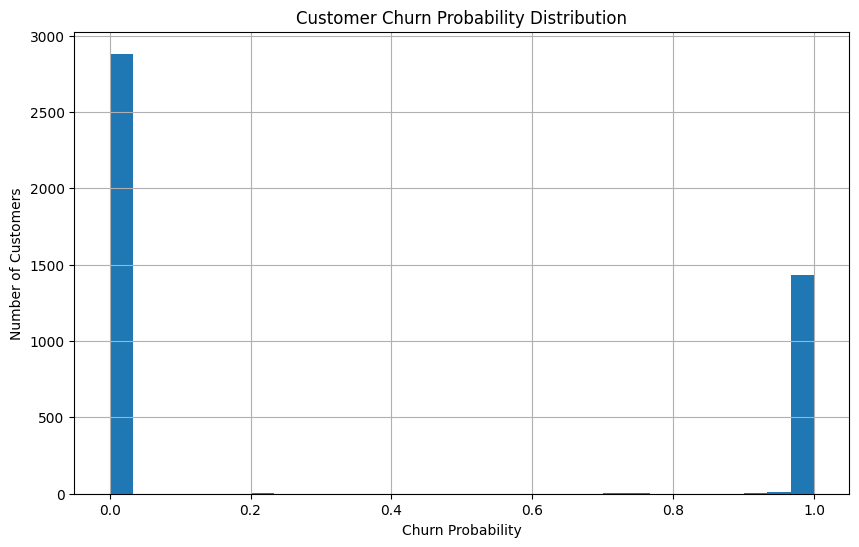

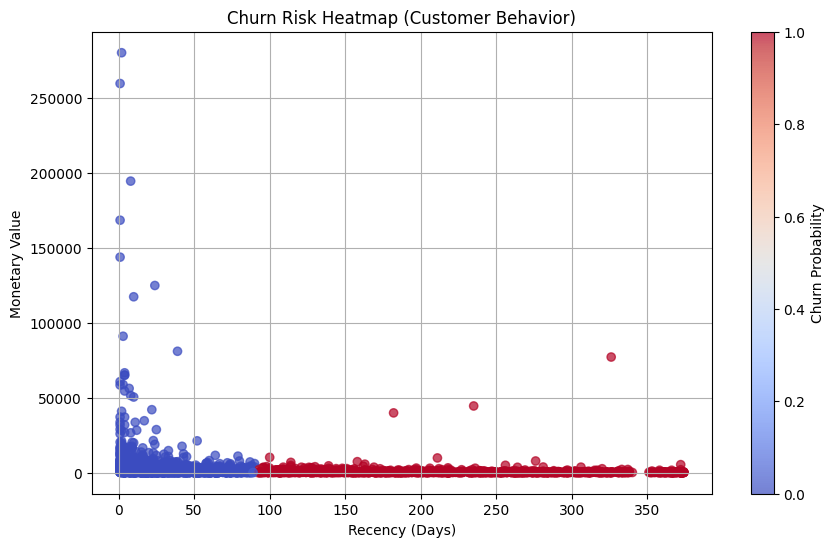

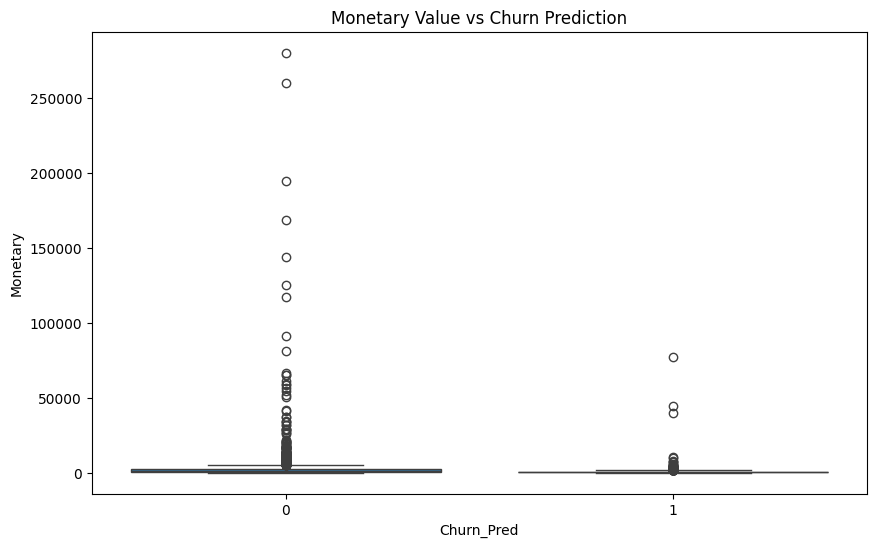

In [15]:
churn_threshold = 90  # days

rfm['Churn'] = (rfm['Recency'] > churn_threshold).astype(int)

features = ['Recency', 'Frequency', 'Monetary']

X = rfm[features]
y = rfm['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = LogisticRegression()
model.fit(X_train, y_train)

rfm['Churn_Prob'] = model.predict_proba(X)[:, 1]
rfm['Churn_Pred'] = model.predict(X)

print(classification_report(y_test, model.predict(X_test)))

plt.figure(figsize=(10,6))
plt.hist(rfm['Churn_Prob'], bins=30)
plt.title("Customer Churn Probability Distribution")
plt.xlabel("Churn Probability")
plt.ylabel("Number of Customers")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,6))

plt.scatter(
    rfm['Recency'],
    rfm['Monetary'],
    c=rfm['Churn_Prob'],
    cmap='coolwarm',
    alpha=0.7
)

plt.colorbar(label="Churn Probability")
plt.xlabel("Recency (Days)")
plt.ylabel("Monetary Value")
plt.title("Churn Risk Heatmap (Customer Behavior)")
plt.grid(True)
plt.show()

import seaborn as sns

plt.figure(figsize=(10,6))

sns.boxplot(x='Churn_Pred', y='Monetary', data=rfm)

plt.title("Monetary Value vs Churn Prediction")
plt.show()

def label_customer(row):
    if row['Churn_Prob'] > 0.7:
        return "High Churn Risk"
    elif row['Churn_Prob'] > 0.4:
        return "Medium Risk"
    else:
        return "Low Risk / Loyal"

rfm['Churn_Segment'] = rfm.apply(label_customer, axis=1)